# STOR 120: Midterm 2 Interactive Comprehensive Practice Lab
### Consolidated Study Guide & Lab Notebook (Classes 11 through 20)

Welcome to the **STOR 120 Midterm 2 Interactive Practice Lab**! This notebook covers all core topics tested on Midterm 2, structured like your weekly STOR 120 labs:

1. **Review the Concept Refresher** for each topic.
2. **Complete the scaffolded code cells** by replacing the ellipsis (`...`) placeholders with your own Python code.
3. **Execute the check cells** (`assert` statements) to verify that your variables, data types, and outputs are accurate.

---

## Environment Setup
Run the cell below to import `datascience`, `numpy`, `matplotlib`, and configure plotting defaults.

In [1]:
# Environment Setup Cell
from datascience import *
import numpy as np
import matplotlib.pyplot as plots
%matplotlib inline
plots.style.use('fivethirtyeight')

print("✅ Setup complete! Course libraries imported.")

✅ Setup complete! Course libraries imported.


---
## Module 1: Iteration, Logic & Control Flow (Class 11)

### Concept Refresher
* **Comparison Operators:** Return Booleans (`True` or `False`): `>`, `<`, `>=`, `<=`, `==` (equality), `!=` (not equal).
* **Logical Operators:** `and` (both true), `or` (at least one true), `not`.
* **Boolean Aggregation:** Python treats `True` as `1` and `False` as `0`. Thus, `np.count_nonzero(boolean_array)` or `sum(boolean_array)` counts `True` values, while `np.mean(boolean_array)` calculates the proportion of `True` values.
* **Control Statements:**
  ```python
  if condition_1:
      # Code block 1
  elif condition_2:
      # Code block 2
  else:
      # Default code block
  ```
* **Loop Accumulation:** Building simulations by initializing an empty array (`make_array()`), running a `for` loop over `np.arange(N)`, and appending outcomes using `results = np.append(results, new_value)`.

### Question 1.1: Tracing Boolean Logic & Counting Conditions
Given the array `scores = make_array(88, 92, 75, 64, 90, 82, 58, 95)`, complete the code below to:
1. Count how many scores are **greater than or equal to 80 AND strictly less than 95**. Assign this integer to `q1_1_count`.
2. Compute the proportion of scores that are **below 70 OR above 90**. Assign this float to `q1_1_prop`.

In [20]:
scores = make_array(88, 92, 75, 64, 90, 82, 58, 95)

q1_1_count = sum(80 <= s and s < 95 for s in scores)
q1_1_prop = sum(s < 70 or s > 90 for s in scores) / len(scores)

print("Count [80, 95):", q1_1_count)
print("Proportion <70 or >90:", q1_1_prop)

Count [80, 95): 4
Proportion <70 or >90: 0.5


In [21]:
# Question 1.1 Check Cell
assert q1_1_count == 4, "q1_1_count should be 4 (88, 92, 90, 82)."
assert np.isclose(q1_1_prop, 0.5), "q1_1_prop should be 4/8 = 0.5 (64, 58, 92, 95)."
print("✅ Question 1.1 passed!")

✅ Question 1.1 passed!


### Question 1.2: Writing Conditional Functions
Define a function named `assign_grade(score)` that takes a numerical score and returns:
* `'High Honors'` if `score >= 90`
* `'Honors'` if `80 <= score < 90`
* `'Pass'` if `60 <= score < 80`
* `'Fail'` if `score < 60`

In [24]:
def assign_grade(score):
    if score >= 90:
        return "High Honors"
    elif score > 80:
        return "Honors"
    elif score > 60:
        return "Pass"
    else:
        return "Fail"

# Test your function
print("Score 85 grade:", assign_grade(85))

Score 85 grade: Honors


In [25]:
# Question 1.2 Check Cell
assert assign_grade(95) == 'High Honors', "Failed for score 95."
assert assign_grade(90) == 'High Honors', "Failed for boundary score 90."
assert assign_grade(85) == 'Honors', "Failed for score 85."
assert assign_grade(70) == 'Pass', "Failed for score 70."
assert assign_grade(55) == 'Fail', "Failed for score 55."
print("✅ Question 1.2 passed!")

✅ Question 1.2 passed!


### Question 1.3: For Loop Simulation & Array Accumulation
Simulate rolling a fair 6-sided die 10,000 times using a `for` loop. Track how many times a **6** is rolled.
1. Create a die face array `die_faces = np.arange(1, 7)`.
2. Initialize an empty array `sim_rolls = make_array()`.
3. Write a `for` loop that runs 10,000 times. In each iteration, draw 1 face using `np.random.choice(die_faces)` and append it to `sim_rolls`.
4. Calculate the total number of 6s rolled and store it in `total_sixes`.

In [116]:
np.random.seed(42) # Set seed for reproducibility

die_faces = np.arange(1, 7)
sim_rolls = make_array()

for roll_index in np.arange(10000):
    one_roll = np.random.choice(die_faces)
    sim_rolls = np.append(sim_rolls, one_roll)

total_sixes = sum([True if i == 6 else False for i in sim_rolls])
print("Total 6s rolled in 10,000 trials:", total_sixes)

Total 6s rolled in 10,000 trials: 1657


In [117]:
# Question 1.3 Check Cell
assert len(sim_rolls) == 10000, "sim_rolls must contain exactly 10,000 items."
assert 1400 <= total_sixes <= 1900, "total_sixes should be near 10,000 / 6 = 1667."
print("✅ Question 1.3 passed!")

✅ Question 1.3 passed!


---
## Module 2: Chance & Probability Rules (Class 12)

### Concept Refresher
* **Probability Scale:** $0 \le P(A) \le 1$.
* **Complement Rule:** $P(\text{not } A) = 1 - P(A)$.
* **Equally Likely Outcomes:** $P(A) = \frac{\text{Outcomes favoring } A}{\text{Total possible outcomes}}$.
* **Multiplication Rule (Sequential Events):** $P(A \text{ and } B) = P(A) \times P(B \mid A)$.
* **Addition Rule (Mutually Exclusive Events):** $P(A \text{ or } B) = P(A) + P(B)$.
* **"At Least One Success" Formula:**
  $$P(\text{at least one success in } n \text{ trials}) = 1 - P(\text{all } n \text{ trials fail}) = 1 - \big(P(\text{single trial fails})\big)^n$$
* **Monty Hall Problem:** Staying yields a $\frac{1}{3}$ win probability; switching yields a $\frac{2}{3}$ win probability.

### Question 2.1: Drawing Without Replacement Math
A box contains 5 Red, 3 Blue, and 2 Green tickets (10 total). You draw 2 tickets **without replacement**.
Calculate the exact probability of drawing a **Green ticket first, followed by a Red ticket**.
Assign this float to `p_green_then_red`.

In [120]:
p_green_then_red = 2/10 * 5/9
print("P(Green then Red):", p_green_then_red)

P(Green then Red): 0.1111111111111111


In [121]:
# Question 2.1 Check Cell
expected_p = (2/10) * (5/9)
assert np.isclose(p_green_then_red, expected_p), "Check your multiplication steps: (2/10) * (5/9) = 10/90 = 0.1111."
print("✅ Question 2.1 passed!")

✅ Question 2.1 passed!


### Question 2.2: "At Least One Success" Probability Calculation
What is the probability of getting **at least one 6** when rolling a fair 6-sided die **4 independent times**?
Assign your mathematical result to `p_at_least_one_six`.

In [124]:
p_at_least_one_six = 1 - (5/6 * 5/6 * 5/6 * 5/6)
print("P(At least one 6 in 4 rolls):", p_at_least_one_six)

P(At least one 6 in 4 rolls): 0.5177469135802468


In [125]:
# Question 2.2 Check Cell
expected_p_6 = 1 - (5/6)**4
assert np.isclose(p_at_least_one_six, expected_p_6), "Use 1 - (5/6)^4 = 1 - 0.48225 = 0.5177."
print("✅ Question 2.2 passed!")

✅ Question 2.2 passed!


---
## Module 3: Sampling, Empirical Distributions & Inference (Class 13)

### Concept Refresher
* **Population vs. Sample:** A **population** is the full set of individuals; a **sample** is a drawn subset.
* **Parameter vs. Statistic:** A **parameter** is a fixed numerical truth about a population (e.g., true population median delay); a **statistic** is a numerical value calculated from a sample (e.g., sample median).
* **Sampling Types:**
  * *Deterministic:* No chance involved (`.take()`, `.where()`).
  * *Probability / Simple Random Sample (SRS):* Drawn at random with known selection probabilities (`t.sample(n)`).
  * *Convenience Sample:* Non-random selection introducing systematic bias.
* **Law of Large Numbers (Law of Averages):** As sample size $n$ or simulation repetitions $N$ increases, the empirical distribution converges toward the true theoretical probability distribution.

### Question 3.1: Sampling from a Table
Run the cell below to create the `flights` population table.

In [126]:
# Create population flights table
np.random.seed(120)
delays = np.random.exponential(scale=15, size=5000) - 5
flights = Table().with_columns(
    'Flight ID', np.arange(1, 5001),
    'Delay', delays
)
flights.show(3)

Flight ID,Delay
1,11.996
2,5.7911
3,9.66076


Draw a **Simple Random Sample of 250 flights** from `flights` **without replacement**.
1. Assign the sampled table to `sample_250`.
2. Compute the sample median delay and assign it to `sample_median_delay`.
3. Compute the true population median delay from `flights` and assign it to `pop_median_delay`.

In [128]:
sample_250 = flights.sample(250)
sample_median_delay = np.median(sample_250.column("Delay"))
pop_median_delay = np.median(flights.column("Delay"))

print("Sample Median Delay:", sample_median_delay)
print("Population Median Delay:", pop_median_delay)

Sample Median Delay: 4.8829666282
Population Median Delay: 5.65575288327


In [129]:
# Question 3.1 Check Cell
assert isinstance(sample_250, Table), "sample_250 must be a Table."
assert sample_250.num_rows == 250, "sample_250 must have exactly 250 rows."
assert isinstance(sample_median_delay, (float, np.float64)), "sample_median_delay must be a float."
assert isinstance(pop_median_delay, (float, np.float64)), "pop_median_delay must be a float."
print("✅ Question 3.1 passed!")

✅ Question 3.1 passed!


### Question 3.2: Empirical Distribution of a Statistic
Simulate the **empirical sampling distribution of the sample median delay** for samples of size $n=100$:
1. Initialize an empty collection array `sim_sample_medians = make_array()`.
2. Write a `for` loop running **1,000 iterations**.
3. In each iteration, draw a random sample of 100 flights (with replacement), compute its sample median delay, and append it to `sim_sample_medians`.

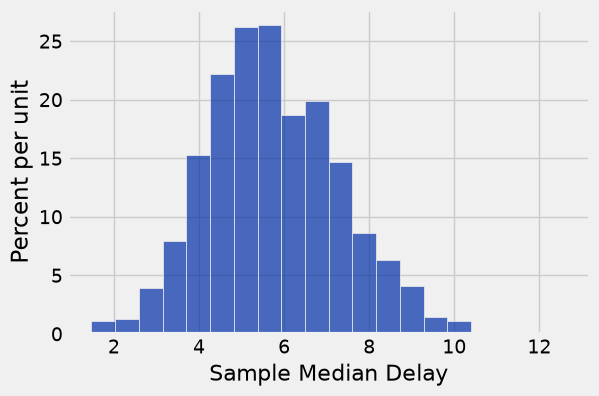

In [133]:
np.random.seed(120)

sim_sample_medians = make_array()

for i in np.arange(1000):
    one_sample = flights.sample(100, with_replacement=True).column("Delay")
    one_median = np.median(one_sample)
    sim_sample_medians = np.append(sim_sample_medians, one_median)

# Plot empirical histogram of sample medians
Table().with_column('Sample Median Delay', sim_sample_medians).hist(bins=20)

In [134]:
# Question 3.2 Check Cell
assert len(sim_sample_medians) == 1000, "sim_sample_medians must contain 1,000 values."
assert np.abs(np.mean(sim_sample_medians) - pop_median_delay) < 3.0, "Empirical mean of medians should center near true population median."
print("✅ Question 3.2 passed!")

✅ Question 3.2 passed!


---
## Module 4: Models & Categorical Sampling (Class 14)

### Concept Refresher
* **Model:** A set of chance assumptions about data generation.
* **`sample_proportions(sample_size, pop_distribution)`:**
  * `sample_size`: Number of categorical draws to simulate.
  * `pop_distribution`: Array or list of category probabilities in the population (must sum to 1.0).
  * *Returns:* Array of sampled category **proportions** in the exact same order.
* **Converting Proportions to Counts:** Multiply the sampled proportion by `sample_size` (e.g., `sample_proportions(100, dist).item(0) * 100`).

### Question 4.1: `sample_proportions()` Mechanics
A bag of candy contains 50% Chocolate, 30% Fruit, and 20% Mint candies (`pop_dist = make_array(0.50, 0.30, 0.20)`).
Write code to simulate drawing **200 candies** at random with replacement.
1. Assign the array of 3 sampled proportions to `candy_sample_props`.
2. Extract the simulated **number (count) of Chocolate candies** drawn and store it in `sim_chocolate_count`.

In [167]:
np.random.seed(120)

pop_dist = make_array(0.50, 0.30, 0.20)
candy_sample_props = sample_proportions(200, pop_dist)
sim_chocolate_count = candy_sample_props[1] * 200

print("Sample Proportions [Choc, Fruit, Mint]:", candy_sample_props)
print("Simulated Chocolate Count:", sim_chocolate_count)

Sample Proportions [Choc, Fruit, Mint]: [ 0.5   0.31  0.19]
Simulated Chocolate Count: 62.0


In [168]:
# Question 4.1 Check Cell
assert len(candy_sample_props) == 3, "candy_sample_props must have 3 elements."
assert np.isclose(np.sum(candy_sample_props), 1.0), "Proportions must sum to 1.0."
assert isinstance(sim_chocolate_count, (float, np.float64, int)), "sim_chocolate_count must be numerical."
print("✅ Question 4.1 passed!")

✅ Question 4.1 passed!


### Question 4.2: *Swain v. Alabama* Simulation Case Study
In Talladega County, AL (1965), **26%** of eligible jurors were Black men. A jury panel of **100 people** contained only **8 Black men** ($8\%$).
Simulate 5,000 random 100-person panels under the null model ($26\%$ Black, $74\%$ not Black):
1. Initialize `sim_black_counts = make_array()`.
2. Write a `for` loop running 5,000 times.
3. In each iteration, draw 100 people using `sample_proportions(100, make_array(0.26, 0.74))`, multiply the first proportion by 100, and append to `sim_black_counts`.
4. Compute the empirical P-value (proportion of simulated panels with $\le 8$ Black men) and store it in `swain_p_value`.

In [195]:
np.random.seed(120)

null_dist = make_array(0.26, 0.74)
sim_black_counts = make_array()

for i in np.arange(5000):
    panel_prop = sample_proportions(100, null_dist).item(0) * 100
    sim_black_counts = np.append(sim_black_counts, panel_prop)

swain_p_value = sum(sim_black_counts <= 8)
print("Swain v. Alabama Simulated P-value:", swain_p_value)

Swain v. Alabama Simulated P-value: 0


In [ ]:
# Question 4.2 Check Cell
assert len(sim_black_counts) == 5000, "Must run 5,000 simulation trials."
assert swain_p_value == 0.0, "In 5,000 random panels, getting 8 or fewer Black panelists under H0 should occur 0 times (P-value = 0.0)."
print("✅ Question 4.2 passed!")

✅ Question 4.2 passed!


: 

---
## Module 5: Decisions, Uncertainty & Total Variation Distance (Class 15)

### Concept Refresher
* **Null Hypothesis ($H_0$):** Clear chance model assuming observed data occurred due to ordinary chance variation alone.
* **Alternative Hypothesis ($H_1$):** View stating a factor other than chance created the pattern.
* **Total Variation Distance (TVD):** Summary test statistic for multi-category distributions:
  $$\text{TVD} = \frac{1}{2} \sum_{\text{all categories}} |\text{Sample \%} - \text{Model \%}|$$
* **P-Value (Observed Significance Level):** The probability, assuming $H_0$ is true, of getting a test statistic as or more extreme than observed in the direction favoring $H_1$.
* **Decision Rules & Error Types:**
  * Reject $H_0$ if $p \le 0.05$; Fail to reject $H_0$ if $p > 0.05$.
  * **Type I Error (False Positive):** Rejecting $H_0$ when $H_0$ is actually **true** (probability $= \alpha$).
  * **Type II Error (False Negative):** Failing to reject $H_0$ when $H_1$ is actually **true**.

### Question 5.1: TVD Function Implementation & Calculation
A cafeteria model predicts student meal choices: `[0.45, 0.35, 0.20]` for `[Pizza, Salad, Sandwich]`. A sample of 300 students yields observed proportions `[0.55, 0.25, 0.20]`.

1. Write a Python function `total_variation_distance(dist1, dist2)` that computes and returns the TVD between two distribution arrays.
2. Compute the TVD between the cafeteria model and observed sample, assigning the result to `sample_tvd`.

In [ ]:
def total_variation_distance(dist1, dist2):
    ...

model_dist = make_array(0.45, 0.35, 0.20)
observed_dist = make_array(0.55, 0.25, 0.20)

sample_tvd = ...
print("Calculated TVD:", sample_tvd)

In [ ]:
# Question 5.1 Check Cell
test_d1 = make_array(0.5, 0.5)
test_d2 = make_array(0.7, 0.3)
assert total_variation_distance(test_d1, test_d2) == 0.2, "TVD function error on test arrays."
assert np.isclose(sample_tvd, 0.10), "Calculated TVD should be (|0.55-0.45| + |0.25-0.35| + |0.20-0.20|)/2 = 0.20/2 = 0.10."
print("✅ Question 5.1 passed!")

---
## Module 6: A/B Testing & Permutation Tests (Class 16 & 17)

### Concept Refresher
* **A/B Testing:** Comparing numerical distributions between two samples (Group A vs Group B).
* **Hypotheses:**
  * $H_0$: Group A and Group B come from the same underlying population distribution. Sample differences are due to chance assignment.
  * $H_1$: One group has systematically different values than the other.
* **Test Statistic:** Difference between group means ($\text{Mean}_A - \text{Mean}_B$).
* **Permutation Test Engine:** Shuffle group labels without replacement using `t.sample(with_replacement=False).column('Group Label')`.

### Question 6.1: Writing the Difference of Means Function
Run the cell below to load the newborn birth weights table (`births`).

In [ ]:
# Setup births table
np.random.seed(42)
smoker_weights = np.random.normal(loc=113, scale=18, size=459)
non_smoker_weights = np.random.normal(loc=123, scale=17, size=715)

births = Table().with_columns(
    'Birth Weight', np.append(smoker_weights, non_smoker_weights),
    'Maternal Smoker', np.append(np.repeat(True, 459), np.repeat(False, 715))
)
births.show(3)

Write a function `difference_of_means(table, group_label, value_label)` that:
1. Groups `table` by `group_label` and computes the mean of `value_label`.
2. Returns the difference: $(\text{Mean of True Group}) - (\text{Mean of False Group})$.

In [ ]:
def difference_of_means(table, group_label, value_label):
    means_table = ...
    mean_true = ...
    mean_false = ...
    return ...

observed_diff = difference_of_means(births, 'Maternal Smoker', 'Birth Weight')
print("Observed Difference (Smoker - Non-Smoker):", observed_diff)

In [ ]:
# Question 6.1 Check Cell
assert np.isclose(observed_diff, -10.0, atol=2.0), "Observed difference should be near -10.0 oz."
print("✅ Question 6.1 passed!")

### Question 6.2: Complete Permutation Simulation Loop
Perform a **Permutation Test** with 1,000 iterations under $H_0$:
1. Initialize `sim_shuffled_diffs = make_array()`.
2. In each iteration, shuffle the `'Maternal Smoker'` column using `births.sample(with_replacement=False).column('Maternal Smoker')`.
3. Create `shuffled_table` using `births.with_column('Shuffled Label', shuffled_labels)`.
4. Compute the difference of means on `shuffled_table` using `difference_of_means(shuffled_table, 'Shuffled Label', 'Birth Weight')` and append it to `sim_shuffled_diffs`.
5. Compute the empirical P-value (proportion of simulated differences $\le$ `observed_diff`) and assign it to `ab_p_value`.

In [ ]:
np.random.seed(42)

sim_shuffled_diffs = ...

for ... in ...:
    shuffled_labels = ...
    shuffled_table = ...
    sim_diff = ...
    sim_shuffled_diffs = ...

ab_p_value = ...
print("Permutation Test P-value:", ab_p_value)

# Plot empirical null distribution
Table().with_column('Simulated Mean Difference under H0', sim_shuffled_diffs).hist(bins=20)

In [ ]:
# Question 6.2 Check Cell
assert len(sim_shuffled_diffs) == 1000, "sim_shuffled_diffs must contain 1,000 values."
assert ab_p_value == 0.0, "An observed difference near -10 oz should produce a P-value of 0.0 under H0."
print("✅ Question 6.2 passed!")

---
## Module 7: Bootstrap Resampling & Confidence Intervals (Classes 19 & 20)

### Concept Refresher
* **The Bootstrap:** Resampling **with replacement** from an original random sample of size $n$, drawing a resample of the **exact same size $n$**.
* **Why it works:** The sample serves as a proxy for the population; resampling from the sample simulates drawing new samples from the population.
* **95% Confidence Interval:** The central 95% of the empirical bootstrap distribution, bounded by the **2.5th percentile** and **97.5th percentile** (`percentile(2.5, array)` and `percentile(97.5, array)`).

### Question 7.1: Bootstrap Resampling for Population Median
Given a sample of 200 flight delays `sample_200 = flights.sample(200, with_replacement=False)`:
1. Construct 1,000 bootstrap resamples of size 200 with replacement.
2. For each resample, compute the sample median delay and store it in `bootstrap_medians`.
3. Compute the **95% Confidence Interval** for the median delay using `percentile(2.5, bootstrap_medians)` and `percentile(97.5, bootstrap_medians)`. Store the bounds in `ci_lower` and `ci_upper`.

In [ ]:
np.random.seed(120)

sample_200 = flights.sample(200, with_replacement=False)
bootstrap_medians = ...

for ... in ...:
    resample = ...
    resample_median = ...
    bootstrap_medians = ...

ci_lower = ...
ci_upper = ...

print("95% Confidence Interval for Median Delay: [", ci_lower, ",", ci_upper, "]")

In [ ]:
# Question 7.1 Check Cell
assert len(bootstrap_medians) == 1000, "bootstrap_medians must contain 1,000 values."
assert ci_lower < ci_upper, "ci_lower must be strictly less than ci_upper."
assert ci_lower <= pop_median_delay <= ci_upper or np.abs(ci_lower - pop_median_delay) < 5.0, "Check confidence interval bounds."
print("✅ Question 7.1 passed!")

---
## Summary Cheat Sheet: Key STOR 120 Midterm 2 Functions

| Category | Function / Method | Purpose & Notes |
| :--- | :--- | :--- |
| **Random Choice** | `np.random.choice(array, n)` | Samples `n` items randomly **with replacement** from an array. |
| **Table Sampling** | `t.sample(n, with_replacement=True)` | Draws `n` sample rows from a table. |
| **Permutations** | `t.sample(with_replacement=False)` | Shuffles/permutes all rows of a table without replacement. |
| **Categorical Draws**| `sample_proportions(n, pop_dist)` | Samples $n$ items from categorical probabilities; returns sample proportions. |
| **Logic & Counting** | `np.count_nonzero(bool_arr)` | Counts `True` values in a Boolean array. |
| **Mean / Proportion**| `np.mean(bool_arr)` | Computes the proportion of `True` values in a Boolean array. |
| **Absolute Value** | `np.abs(array)` | Computes absolute values (used in TVD). |
| **Percentiles** | `percentile(p, array)` | Finds the $p$-th percentile of an array (e.g. 2.5 and 97.5 for 95% CIs). |

---
## Congratulations! You've Completed the Midterm 2 Practice Lab!
To ensure your entire notebook executes cleanly without errors, select **Kernel -> Restart Kernel and Run All Cells**.